## Welfare Bot - Isolation Forest

Tässä notebookissa käytän Isolation Forest -algoritmia poikkeavien hyvinvointitilanteiden tunnistamiseen.
Tavoitteena on löytää havaintoja, joissa käyttäjän hyvinvointimittarit poikkeavat normaalista käyttäytymisestä.

In [2]:
import pandas as pd # pandas auttaa taulukkomuotoisen datan käsittelyssä
import numpy as np # numeeriseen laskentaan
import matplotlib.pyplot as plt # datan visualisointiin

from sklearn.preprocessing import StandardScaler # datan skaalaamiseen, jotta eri mittayksiköt eivät vaikuta mallin oppimiseen
from sklearn.ensemble import IsolationForest # poikkeavuuksien tunnistamiseen, jotta voin tunnistaa ja käsitellä poikkeavia havaintoja datassa

In [3]:
data = pd.read_csv("../data/welfare_bot_metrics_cleaned.csv")

data.head()

,date,user_name,email,mood_score,sleep_score,food_score,hydration_score,medication_score,social_score,overall_score,risk_level
0,2025-01-01,Aino Mäkinen,aino.makinen@demo.fi,4.40,3.94,2.99,1.00,0.88,3.38,8.890,low
1,2025-01-02,Aino Mäkinen,aino.makinen@demo.fi,4.83,4.31,2.66,0.96,0.86,3.27,8.980,low
2,2025-01-03,Aino Mäkinen,aino.makinen@demo.fi,4.30,3.24,2.28,0.80,0.82,3.66,7.670,low
3,2025-01-04,Aino Mäkinen,aino.makinen@demo.fi,3.84,3.44,3.00,0.79,0.91,2.79,7.765,NaN
4,2025-01-05,Aino Mäkinen,aino.makinen@demo.fi,3.99,4.05,2.46,0.94,0.85,3.36,8.250,low


In [ ]:
data["date"] = pd.to_datetime(data["date"]) # muuttaa "date" sarakkeen datetime-muotoon, jotta voin käyttää sitä 
# aikaperusteisissa analyyseissä ja visualisoinneissa.

Käytän tässä notebookissa preprocessing-vaiheessa tallennettua puhdistettua dataa.
Puuttuvat arvot on jo käsitelty aiemmassa notebookissa, joten voin siirtyä suoraan koneoppimismallin rakentamiseen.

In [5]:
# valitaan Isolation Forest mallille käytettävät featuret
features = [
    "mood_score",
    "sleep_score",
    "food_score",
    "hydration_score",
    "medication_score",
    "social_score",
    "overall_score"
]

X = data[features]

X.head()

,mood_score,sleep_score,food_score,hydration_score,medication_score,social_score,overall_score
0,4.40,3.94,2.99,1.00,0.88,3.38,8.890
1,4.83,4.31,2.66,0.96,0.86,3.27,8.980
2,4.30,3.24,2.28,0.80,0.82,3.66,7.670
3,3.84,3.44,3.00,0.79,0.91,2.79,7.765
4,3.99,4.05,2.46,0.94,0.85,3.36,8.250


En käytä sarakkeita user_name, email, date ja risk_level mallin featureina.
Ne ovat hyödyllisiä datan tunnistamiseen, visualisointiin ja tulosten tulkintaan, mutta ne eivät ole numeerisia hyvinvointimittareita.

## Datan skaalaus

Hyvinvointimittarit ovat eri asteikoilla, joten skaalaan datan ennen Isolation Forest -mallin käyttöä.
Esimerkiksi:
'hydration_score' on välillä 0-1; 'social_score' on välillä 0–5; 'overall_score'on noin välillä 4–10. 
Ilman skaalausta suuremmat arvot voisivat vaikuttaa malliin enemmän kuin pienemmät arvot.

In [6]:
# luodaan scaler-objekti
scaler = StandardScaler()
# skaalataan featuret
X_scaled = scaler.fit_transform(X)

In [7]:
# tarkastellaan skaalatun datan ensimmäisiä rivejä
X_scaled[:5]

array([[ 1.30894076,  0.52443969,  1.06695892,  1.23387646, -0.19998247,
         1.00930016,  1.55201652],
       [ 2.10444325,  1.00271111,  0.29067515,  1.03882287, -0.47838035,
         0.89497506,  1.66410695],
       [ 1.12394018, -0.38039813, -0.60322738,  0.25860854, -1.0351761 ,
         1.30030953,  0.0325685 ],
       [ 0.27293752, -0.12187304,  1.09048267,  0.20984515,  0.21761434,
         0.39610186,  0.15088617],
       [ 0.55043839,  0.66662849, -0.17979987,  0.94129608, -0.61757929,
         0.98851378,  0.75492903]])

## Isolation Forest -mallin kouluttaminen

Koulutan Isolation Forest - mallin skaalatulla datalla. Algoritmi on unsupervised - se etsii itse datasta poikkeavia havaintoja ilman valmiita vastauksia, ja sen tehtävä tässä on tunnistaa hyvinvoinnin epätavalliset tilanteet.

In [ ]:
# Luodaan Isolation Forest -malli

model = IsolationForest(
    n_estimators=100, # puiden määrä, joka vaikuttaa mallin tarkkuuteen ja laskenta-aikaan
    contamination=0.08, # odotettu poikkeavien havaintojen osuus datassa, joka auttaa mallia erottamaan normaalit 
                        # ja poikkeavat havainnot
    random_state=42 # satunnaissiementäminen, jotta mallin tulokset ovat toistettavissa
)

# Koulutetaan malli skaalatulla datalla
model.fit(X_scaled)

,n_estimators,100
,max_samples,'auto'
,contamination,0.08
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


In [9]:
# malli ennustaa, mitkä havainnot ovat poikkeavia
data["anomaly"] = model.predict(X_scaled)

In [10]:
# katsotaan kuinka monta normaalia ja poikkeavaa havaintoa malli löysi
data["anomaly"].value_counts()

anomaly
 1    552
-1     48
Name: count, dtype: int64

Tässä vaiheessa malli tunnisti datasta poikkeavia havaintoja. Suurin osa havainnoista oli normaaleja, mutta pieni osa poikkesi tavallisesta käyttäytymisestä.

## Poikkeavien havaintojen tarkastelu

Tässä vaiheessa tarkastelen rivejä, jotka Isolation Forest malli tunnisti poikkeaviksi.

In [11]:
# valitaan vain poikkeavat havainnot
anomalies = data[data["anomaly"] == -1]
anomalies.head()

,date,user_name,email,mood_score,sleep_score,food_score,hydration_score,medication_score,social_score,overall_score,risk_level,anomaly
42,2025-02-12,Aino Mäkinen,aino.makinen@demo.fi,5.00,4.47,2.37,0.82,1.00,3.20,8.87,low,-1
43,2025-02-13,Aino Mäkinen,aino.makinen@demo.fi,4.46,4.37,2.55,0.89,0.64,3.05,8.39,low,-1
70,2025-03-12,Aino Mäkinen,aino.makinen@demo.fi,5.00,4.80,2.77,1.00,0.95,4.28,9.63,low,-1
79,2025-03-21,Aino Mäkinen,aino.makinen@demo.fi,5.00,4.01,3.00,0.95,1.00,4.17,9.35,low,-1
97,2025-04-08,Aino Mäkinen,aino.makinen@demo.fi,4.65,5.00,2.92,0.95,0.86,3.21,9.38,low,-1


## Mallin parametrien säätäminen

Ensimmäinen Isolation Forest malli merkitsi poikkeamiksi myös erittäin korkeita hyvinvointiarvoja, koska algoritmi etsii yleisesti kaikkia epätavallisia havaintoja. Koska projektin tavoite on löytää nimenomaan mahdollisia riskitilanteita, pienensin 'contamination'-parametria, jotta malli merkitsee vain pienemmän osan havainnoista poikkeamiksi.

In [12]:
# Luodaan uusi malli pienemmällä contamination-arvolla
model = IsolationForest(
    n_estimators=100,
    contamination=0.03,
    random_state=42
)

# koulutetaan malli uudelleen skaalatulla datalla
model.fit(X_scaled)

# tehdään uudet ennusteet ja tallennetaan ne "anomaly" sarakkeeseen
data["anomaly"] = model.predict(X_scaled)

In [ ]:
data["anomaly"].value_counts() # katsotaan kuinka monta normaalia ja poikkeavaa havaintoa uudella mallilla löytyi

anomaly
 1    582
-1     18
Name: count, dtype: int64

In [14]:
anomalies = data[data["anomaly"] == -1] # valitaan vain poikkeavat havainnot uudella mallilla
anomalies.head()

,date,user_name,email,mood_score,sleep_score,food_score,hydration_score,medication_score,social_score,overall_score,risk_level,anomaly
70,2025-03-12,Aino Mäkinen,aino.makinen@demo.fi,5.00,4.80,2.77,1.00,0.95,4.28,9.63,low,-1
256,2025-04-17,Eino Virtanen,eino.virtanen@demo.fi,3.65,3.07,1.41,0.23,0.90,3.10,5.85,medium,-1
265,2025-04-26,Eino Virtanen,eino.virtanen@demo.fi,2.99,2.10,1.80,0.78,0.71,1.69,5.79,medium,-1
289,2025-05-20,Eino Virtanen,eino.virtanen@demo.fi,3.65,2.57,1.09,0.45,0.98,2.98,5.80,medium,-1
297,2025-05-28,Eino Virtanen,eino.virtanen@demo.fi,2.70,3.51,1.35,0.38,0.88,1.73,5.63,medium,-1


## Overall score ja poikkeavat havainnot

Tässä visualisoin käyttäjän kokonaisvaltaisen hyvinvoinnin ajan yli sekä Isolation Forest -mallin tunnistamat poikkeavat havainnot.
Punaiset pisteet kuvaavat tilanteita, joissa hyvinvointi poikkesi normaalista käyttäytymisestä.

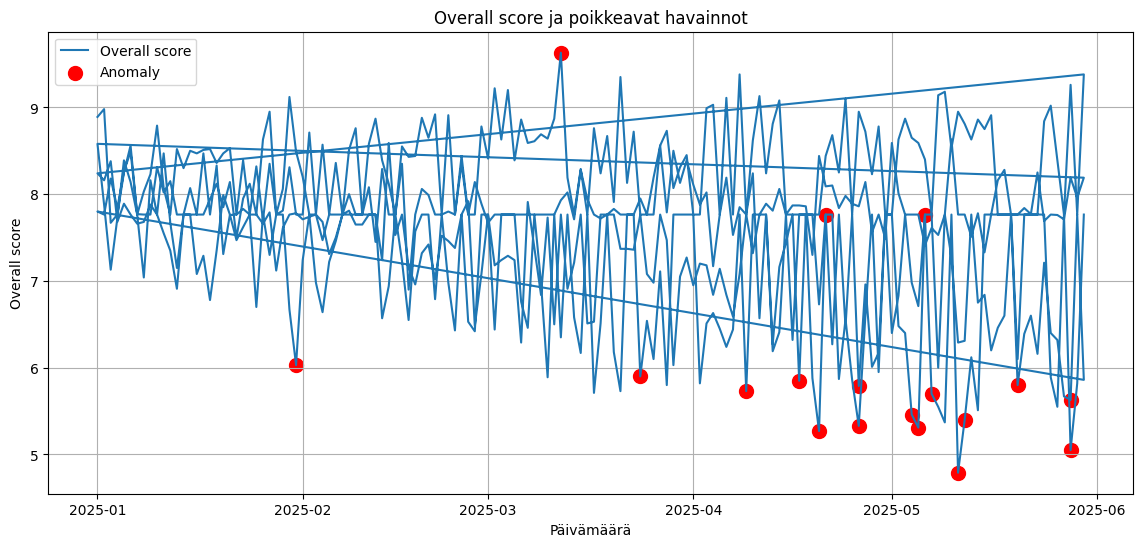

In [ ]:
plt.figure(figsize=(14,6)) # luodaan kuva, jossa on riittävästi tilaa datan visualisointiin

# overall score
plt.plot(
    data["date"],
    data["overall_score"],
    label="Overall score"
)

# anomalies
plt.scatter(
    anomalies["date"],
    anomalies["overall_score"],
    color="red",
    label="Anomaly",
    s=100
)

plt.title("Overall score ja poikkeavat havainnot")

plt.xlabel("Päivämäärä")
plt.ylabel("Overall score")

plt.legend() # näytä selite, joka auttaa erottamaan normaalit ja poikkeavat havainnot kuvasta
plt.grid() # lisää ruudukko kuvaan, jotta pisteiden sijainnit on helpompi hahmottaa
plt.show() # näytä kuva, jossa on overall score ja poikkeavat havainnot  

## Havainnot visualisoinnista

Punaiset pisteet sijoittuivat tyypillisesti kohtiin, joissa overall_score oli matala, muuttui äkillisesti tai vaihteli normaalia enemmän - eli malli löysi nimenomaan niitä tilanteita, joissa käyttäjän hyvinvointi poikkesi tavanomaisesta.

# Poikkeavien havaintojen määrä käyttäjittäin

Tässä visualisoin, kuinka monta poikkeavaa havaintoa Isolation Forest tunnisti jokaiselle käyttäjälle.
Tämä auttaa näkemään, kenellä käyttäjistä esiintyi eniten poikkeavaa hyvinvointikäyttäytymistä.

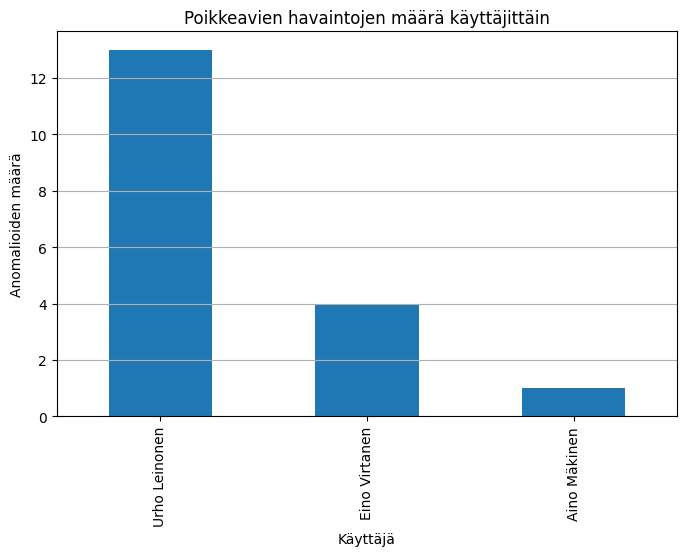

In [ ]:
anomaly_counts = anomalies["user_name"].value_counts()

plt.figure(figsize=(8,5)) # luodaan kuva, jossa on riittävästi tilaa datan visualisointiin

anomaly_counts.plot(kind="bar") # luodaan pylväsdiagrammi, jossa x-akselilla on käyttäjät ja y-akselilla poikkeavien havaintojen määrä

plt.title("Poikkeavien havaintojen määrä käyttäjittäin")

plt.xlabel("Käyttäjä")
plt.ylabel("Anomalioiden määrä")

plt.grid(axis="y") # lisää vaakasuuntainen ruudukko, joka auttaa hahmottamaan pylväiden korkeudet paremmin

plt.show() 

## Havainnot käyttäjäkohtaisista poikkeamista

Poikkeamien määrä vaihteli käyttäjittäin: osalla niitä esiintyi selvästi enemmän, mikä voi viitata epävakaampaan hyvinvointiin tai mahdollisiin riskijaksoihin. Tällainen tieto voisi auttaa Welfare Botia tunnistamaan käyttäjät, jotka tarvitsevat enemmän seurantaa.

# Uni ja kokonaisvaltainen hyvinvointi

Tässä visualisoin unen ja kokonaisvaltaisen hyvinvoinnin välistä yhteyttä.
Punaiset pisteet kuvaavat poikkeavia havaintoja, jotka Isolation Forest tunnisti.

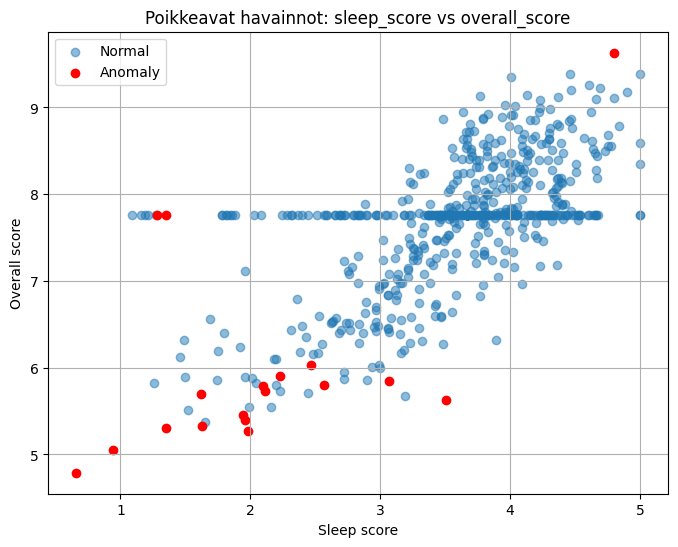

In [ ]:
plt.figure(figsize=(8,6))

# normaalit havainnot
normal = data[data["anomaly"] == 1]

plt.scatter(
    normal["sleep_score"],
    normal["overall_score"],
    label="Normal",
    alpha=0.5
)

# poikkeavat havainnot
plt.scatter(
    anomalies["sleep_score"],
    anomalies["overall_score"],
    color="red",
    label="Anomaly"
)

plt.title("Poikkeavat havainnot: sleep_score vs overall_score")

plt.xlabel("Sleep score")
plt.ylabel("Overall score")

plt.legend() # näytä selite, joka auttaa erottamaan normaalit ja poikkeavat havainnot kuvasta

plt.grid() # lisää ruudukko kuvaan, jotta pisteiden sijainnit on helpompi hahmottaa

plt.show() # näytä kuva, jossa on sleep_score, overall_score ja poikkeavat havainnot

## Havainnot unen ja kokonaisvaltaisen hyvinvoinnin suhteesta

Matala sleep_score yhdistyi usein matalaan overall_scoreen, ja juuri näissä kohdissa malli merkitsi havaintoja poikkeamiksi - eli unen laadulla näyttää olevan selkeä vaikutus käyttäjän yleiseen hyvinvointiin.

# Mieliala ja kokonaisvaltainen hyvinvointi

Tässä visualisoin mielialan ja kokonaisvaltaisen hyvinvoinnin välistä yhteyttä.
Punaiset pisteet kuvaavat poikkeavia havaintoja, jotka Isolation Forest tunnisti.

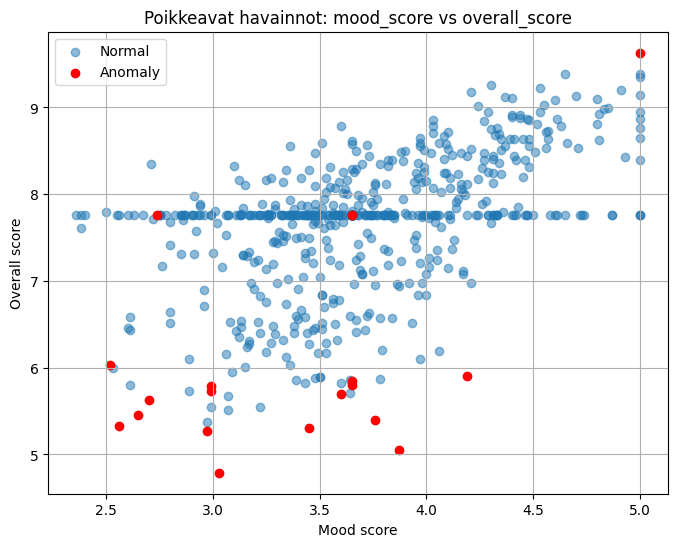

In [ ]:
plt.figure(figsize=(8,6))

# normaalit havainnot
normal = data[data["anomaly"] == 1]

plt.scatter(
    normal["mood_score"],
    normal["overall_score"],
    label="Normal",
    alpha=0.5
)

# poikkeavat havainnot
plt.scatter(
    anomalies["mood_score"],
    anomalies["overall_score"],
    color="red",
    label="Anomaly"
)

plt.title("Poikkeavat havainnot: mood_score vs overall_score")

plt.xlabel("Mood score")
plt.ylabel("Overall score")

plt.legend()
plt.grid()
plt.show()

## Havainnot mielialan ja kokonaisvaltaisen hyvinvoinnin suhteesta

Matala mood_score yhdistyi usein matalaan overall_scoreen, ja malli merkitsi juuri näitä kohtia poikkeamiksi - mieliala on selvästi tärkeä osa käyttäjän hyvinvointia.

# Ruokailu ja kokonaisvaltainen hyvinvointi

Tässä visualisoin ruokailun ja kokonaisvaltaisen hyvinvoinnin välistä yhteyttä.
Punaiset pisteet kuvaavat poikkeavia havaintoja, jotka Isolation Forest tunnisti.

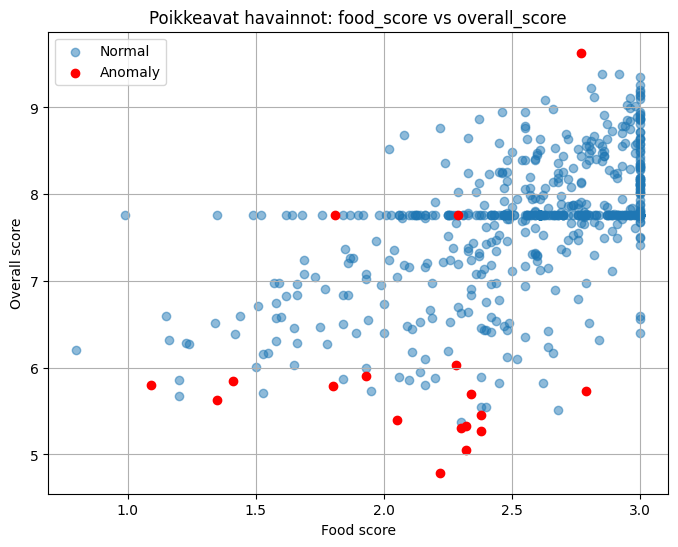

In [ ]:
plt.figure(figsize=(8,6))

# normaalit havainnot
normal = data[data["anomaly"] == 1]

plt.scatter(
    normal["food_score"],
    normal["overall_score"],
    label="Normal",
    alpha=0.5
)

# poikkeavat havainnot
plt.scatter(
    anomalies["food_score"],
    anomalies["overall_score"],
    color="red",
    label="Anomaly"
)

plt.title("Poikkeavat havainnot: food_score vs overall_score")

plt.xlabel("Food score")
plt.ylabel("Overall score")

plt.legend()
plt.grid()
plt.show()

## Havainnot ruokailun ja kokonaisvaltaisen hyvinvoinnin suhteesta

Ruokailu pysyi enimmäkseen vakaana, mutta poikkeamia näkyi tilanteissa, joissa food_score laski normaalia matalammaksi ja overall_score seurasi mukana - ruokailulla on siis vaikutusta yleiseen hyvinvointiin.

# Nesteytys ja kokonaisvaltainen hyvinvointi

Tässä visualisoin nesteytyksen ja kokonaisvaltaisen hyvinvoinnin välistä yhteyttä.
Punaiset pisteet kuvaavat poikkeavia havaintoja, jotka Isolation Forest tunnisti.

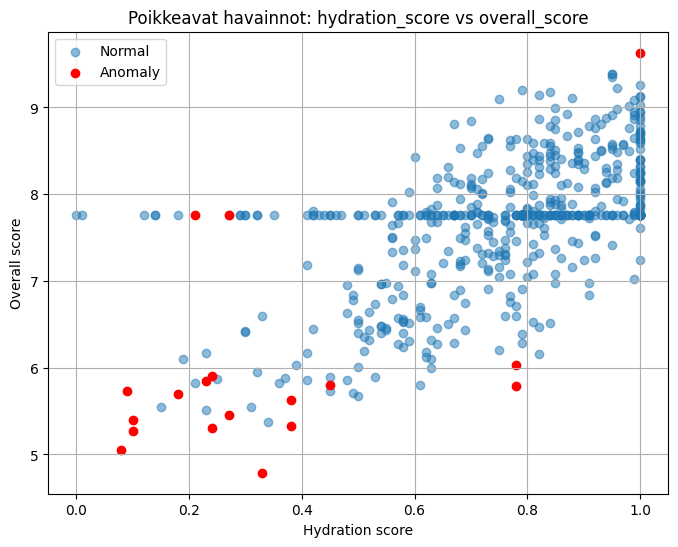

In [26]:
plt.figure(figsize=(8,6))

# normaalit havainnot
normal = data[data["anomaly"] == 1]

plt.scatter(
    normal["hydration_score"],
    normal["overall_score"],
    label="Normal",
    alpha=0.5
)

# poikkeavat havainnot
plt.scatter(
    anomalies["hydration_score"],
    anomalies["overall_score"],
    color="red",
    label="Anomaly"
)

plt.title("Poikkeavat havainnot: hydration_score vs overall_score")

plt.xlabel("Hydration score")
plt.ylabel("Overall score")

plt.legend()

plt.grid()

plt.show()

## Havainnot nesteytyksen ja kokonaisvaltaisen hyvinvoinnin suhteesta

Matala hydration_score yhdistyi usein matalaan overall_scoreen, ja malli merkitsi nämä kohdat poikkeamiksi - riittävä nesteytys näyttää olevan tärkeä osa hyvinvoinnin ylläpitämistä.

# Sosiaalinen aktiivisuus ja kokonaisvaltainen hyvinvointi

Tässä visualisoin sosiaalisen aktiivisuuden ja kokonaisvaltaisen hyvinvoinnin välistä yhteyttä.
Punaiset pisteet kuvaavat poikkeavia havaintoja, jotka Isolation Forest tunnisti.

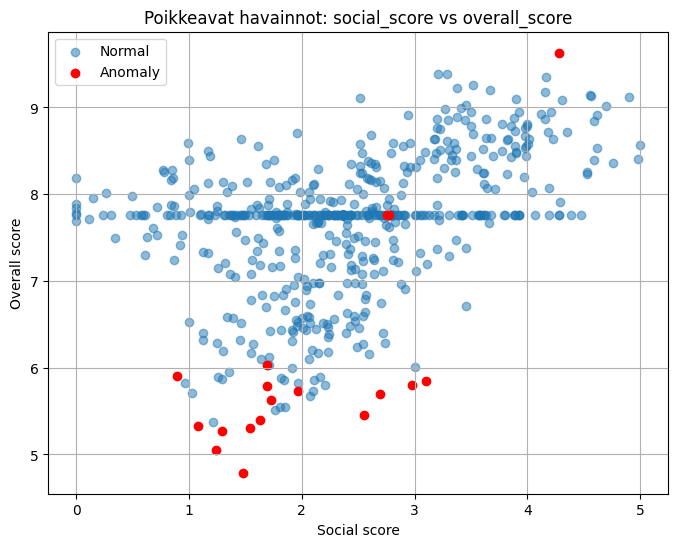

In [27]:
plt.figure(figsize=(8,6))

# normaalit havainnot
normal = data[data["anomaly"] == 1]

plt.scatter(
    normal["social_score"],
    normal["overall_score"],
    label="Normal",
    alpha=0.5
)

# poikkeavat havainnot
plt.scatter(
    anomalies["social_score"],
    anomalies["overall_score"],
    color="red",
    label="Anomaly"
)

plt.title("Poikkeavat havainnot: social_score vs overall_score")

plt.xlabel("Social score")
plt.ylabel("Overall score")

plt.legend()

plt.grid()

plt.show()

## Havainnot sosiaalisen aktiivisuuden ja kokonaisvaltaisen hyvinvoinnin suhteesta

Visualisoinnin perusteella sosiaalinen aktiivisuus vaihteli enemmän kuin monet muut hyvinvointimittarit.
Poikkeavat havainnot liittyivät usein tilanteisiin, joissa:
- sosiaalinen aktiivisuus oli matalampi
- overall_score oli normaalia heikompi

Tämä voi viitata siihen, että sosiaalisella aktiivisuudella on yhteys käyttäjän yleiseen hyvinvointiin.

# Yhteenveto

Tässä projektissa käytin Isolation Forest - algoritmia hyvinvointidatan poikkeamien tunnistamiseen ja huomasin, että uni, mieliala, ruokailu, nesteytys ja sosiaalinen aktiivisuus olivat yhteydessä käyttäjän overall_score-arvoon.

Tulokset tukevat Welfare Bot -projektin ideaa: yksinkertaisten hyvinvointimittareiden säännöllinen seuranta voi auttaa tunnistamaan mahdollisia riskitilanteita aikaisessa vaiheessa.